In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

sns.set_theme(style="whitegrid")

In [249]:
df = pd.read_csv('Social_Network_Ads.csv')

X = df.iloc[:, [0, 1]].values
y = df.iloc[:, 2].values

df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [308]:
RANDOM_STATE = 112
TEST_SIZE = 0.25

In [310]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [312]:
classifier = LogisticRegression(random_state=RANDOM_STATE)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [314]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
error_rate = 1 - accuracy
f1 = 2 * (precision * recall)/(precision + recall)

print(f"--- Confusion Matrix Elements ---")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"\n--- Performance Metrics ---")
print(f"Accuracy:   {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1:    {f1:.4f}")

--- Confusion Matrix Elements ---
True Positives (TP): 28
False Positives (FP): 2
True Negatives (TN): 63
False Negatives (FN): 7

--- Performance Metrics ---
Accuracy:   0.9100
Error Rate: 0.0900
Precision:  0.9333
Recall:     0.8000
F1:    0.8615


In [316]:
# save data to file
with open("results.txt", "a") as file:
    data = [
        f"{RANDOM_STATE=}\n",
        f"{TEST_SIZE=}\n",
        "--- Confusion Matrix Elements ---\n",
        f"True Positives (TP): {tp}\n",
        f"False Positives (FP): {fp}\n",
        f"True Negatives (TN): {tn}\n",
        f"False Negatives (FN): {fn}\n",
        "\n--- Performance Metrics ---\n",
        f"Accuracy:   {accuracy:.4f}\n",
        f"Error Rate: {error_rate:.4f}\n",
        f"Precision:  {precision:.4f}\n",
        f"Recall:     {recall:.4f}\n",
        f"F1:    {f1:.4f}\n\n"
    ]
    file.writelines(data)

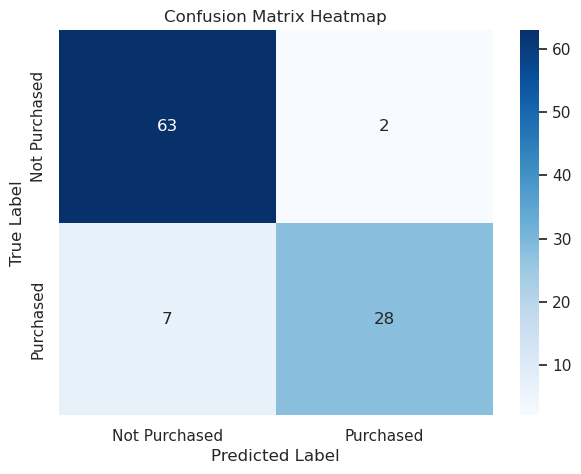

In [318]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Purchased', 'Purchased'], 
            yticklabels=['Not Purchased', 'Purchased'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

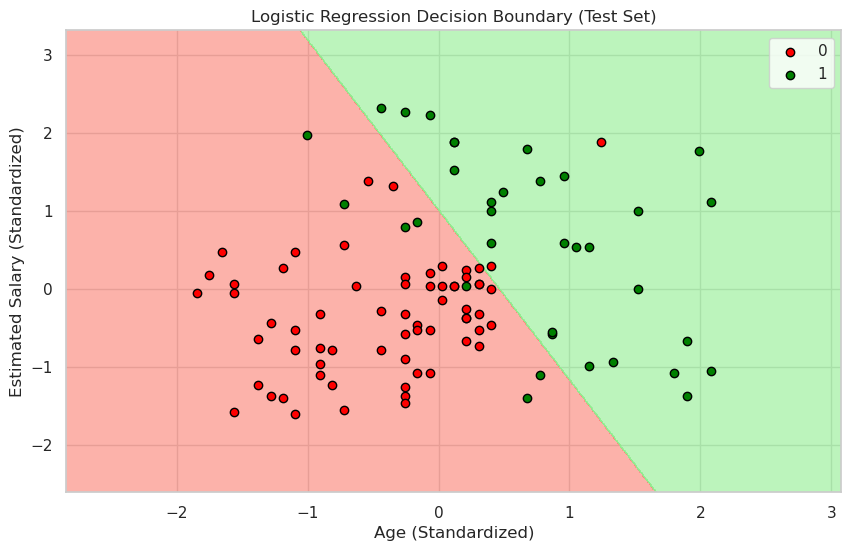

In [320]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.6, cmap=ListedColormap(('salmon', 'lightgreen')))

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color=ListedColormap(('red', 'green'))(i), label=j, edgecolors='black')

plt.title('Logistic Regression Decision Boundary (Test Set)')
plt.xlabel('Age (Standardized)')
plt.ylabel('Estimated Salary (Standardized)')
plt.legend()
plt.show()